# CS4082 – Lab 4: Linear Regression & Its Variants
**Effat University | Department of Computer Science**  
**Prepared by: Dr. Naila Marir | Spring 2026**

by Ahmad Balubaid S23108476

## Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print('All libraries imported successfully!')

All libraries imported successfully!


---
## Part 1: The Idea Behind Linear Regression
**Mathematical Model:**
- Single feature: ŷ = w₁x + w₀
- Multiple features: ŷ = w₀ + w₁x₁ + w₂x₂ + ... + wₙxₙ

**OLS Cost Function:** Cost = Σ(yᵢ - ŷᵢ)²  
Squared errors penalize large mistakes more heavily and prevent positive/negative cancellation.



## Part 2: Loading a Real Dataset – California Housing

In [2]:
# Step 1: Load and Explore
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target  # target in $100,000s

print(f'Dataset shape: {df.shape}')
print(f'\nFeature names:\n{housing.feature_names}')
print(f'\nFirst 5 rows:')
print(df.head())
print(f'\nBasic statistics:')
print(df.describe().round(3))

Dataset shape: (20640, 9)

Feature names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Basic statistics:
          MedInc   HouseAge   AveRooms  AveBedrms  Population   AveOccup  \
count  20640.000  20640.000  20640.000  20640.000   20640.000  20640.000   
mean       3.871     28.639      5.429      1.09

In [3]:
# Step 2: Understand the Features (already documented in the lab)
print('Feature descriptions:')
feature_descriptions = {
    'MedInc':    'Median income of district ($10,000s)',
    'HouseAge':  'Median house age (years)',
    'AveRooms':  'Average rooms per household',
    'AveBedrms': 'Average bedrooms per household',
    'Population':'District population',
    'AveOccup':  'Average household members',
    'Latitude':  'District latitude (degrees)',
    'Longitude': 'District longitude (degrees)',
    'MedHouseVal':'Median house value - TARGET ($100,000s)'
}
for feat, desc in feature_descriptions.items():
    print(f'  {feat:12s}: {desc}')

Feature descriptions:
  MedInc      : Median income of district ($10,000s)
  HouseAge    : Median house age (years)
  AveRooms    : Average rooms per household
  AveBedrms   : Average bedrooms per household
  Population  : District population
  AveOccup    : Average household members
  Latitude    : District latitude (degrees)
  Longitude   : District longitude (degrees)
  MedHouseVal : Median house value - TARGET ($100,000s)


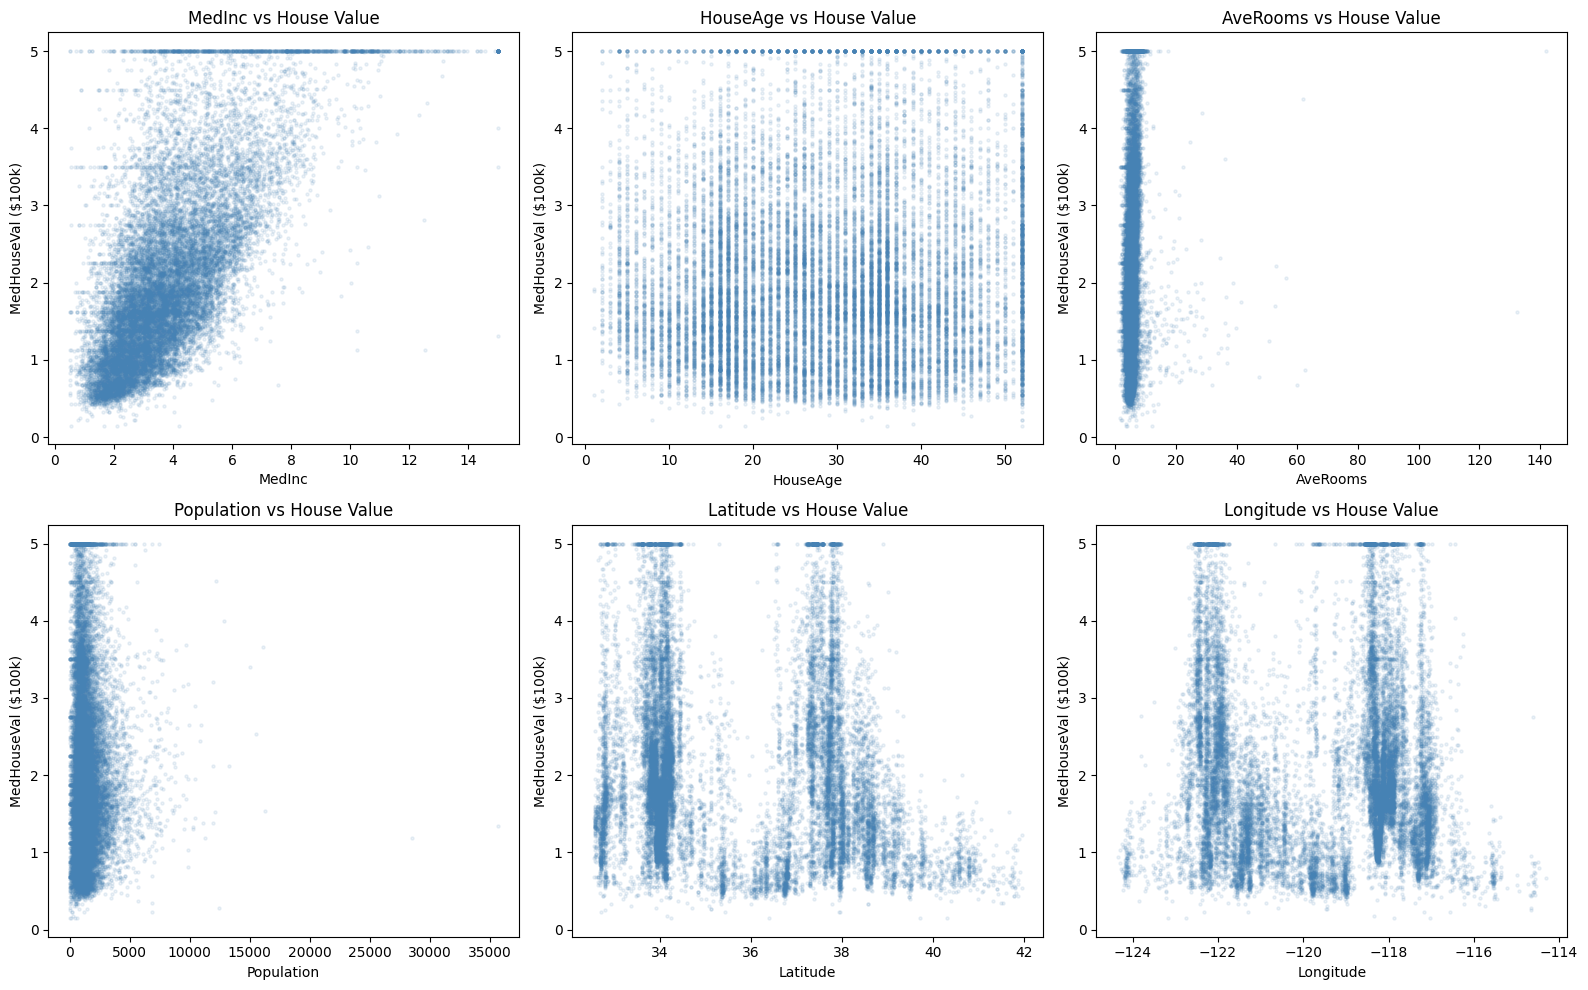

In [4]:
# Step 3: Visualize Relationships
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
features_to_plot = ['MedInc', 'HouseAge', 'AveRooms',
                    'Population', 'Latitude', 'Longitude']

for ax, feat in zip(axes.flatten(), features_to_plot):
    ax.scatter(df[feat], df['MedHouseVal'],
               alpha=0.1, s=5, color='steelblue')
    ax.set_xlabel(feat)
    ax.set_ylabel('MedHouseVal ($100k)')
    ax.set_title(f'{feat} vs House Value')

plt.tight_layout()
plt.show()

---
## ✅ TASK 1: Explore the Dataset

In [5]:
# TASK 1a: Rank features by correlation with target
correlations = df.corr()['MedHouseVal'].sort_values()
print('Feature correlations with MedHouseVal (sorted):')
print(correlations)
print(f'\n>>> Strongest positive correlation: {correlations.drop("MedHouseVal").idxmax()} '
      f'({correlations.drop("MedHouseVal").max():.4f})')
print(f'>>> Strongest negative correlation: {correlations.drop("MedHouseVal").idxmin()} '
      f'({correlations.drop("MedHouseVal").min():.4f})')

Feature correlations with MedHouseVal (sorted):
Latitude      -0.144160
AveBedrms     -0.046701
Longitude     -0.045967
Population    -0.024650
AveOccup      -0.023737
HouseAge       0.105623
AveRooms       0.151948
MedInc         0.688075
MedHouseVal    1.000000
Name: MedHouseVal, dtype: float64

>>> Strongest positive correlation: MedInc (0.6881)
>>> Strongest negative correlation: Latitude (-0.1442)


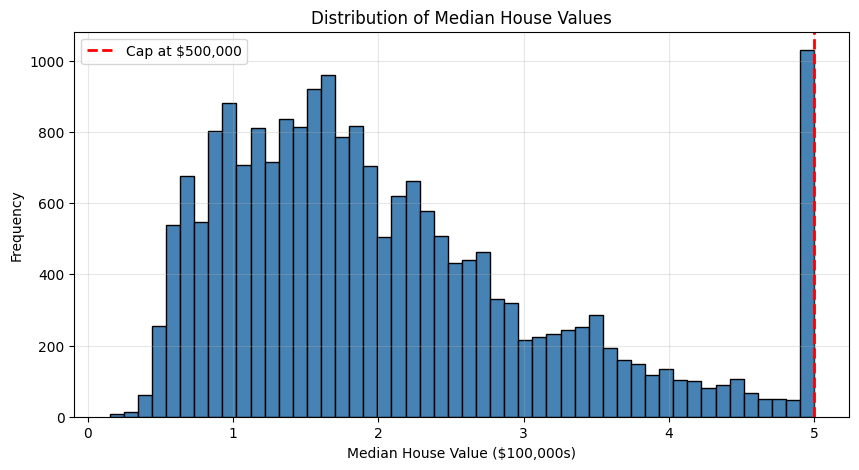

Number of samples at/above the $500,000 cap: 992 (4.8% of dataset)


In [6]:
# TASK 1b: Distribution of MedHouseVal
plt.figure(figsize=(10, 5))
plt.hist(df['MedHouseVal'], bins=50, color='steelblue', edgecolor='black')
plt.axvline(x=5.0, color='red', linestyle='--', linewidth=2, label='Cap at $500,000')
plt.xlabel('Median House Value ($100,000s)')
plt.ylabel('Frequency')
plt.title('Distribution of Median House Values')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

cap_count = (df['MedHouseVal'] >= 5.0).sum()
print(f'Number of samples at/above the $500,000 cap: {cap_count} '
      f'({cap_count/len(df)*100:.1f}% of dataset)')

In [7]:
# TASK 1c: Sample size assessment
print(f'Total samples in dataset: {len(df):,}')
print(f'Training samples (80%): {int(len(df)*0.8):,}')
print(f'Testing samples (20%):  {int(len(df)*0.2):,}')
print()
print('ANSWER: Yes, 20,640 samples is MORE than sufficient for training a good regression model.')
print('As a rule of thumb, you want at least 10x samples per feature.')
print(f'Here we have {len(df)//8:,}x samples per feature — excellent!')

Total samples in dataset: 20,640
Training samples (80%): 16,512
Testing samples (20%):  4,128

ANSWER: Yes, 20,640 samples is MORE than sufficient for training a good regression model.
As a rule of thumb, you want at least 10x samples per feature.
Here we have 2,580x samples per feature — excellent!


**Task 1 Answers:**
- **Strongest correlation**: `MedInc` has the highest positive correlation (~0.69) with house value — higher-income districts have more expensive houses.
- **Distribution**: The target is roughly right-skewed with a clear cap at $5.0 ($500,000), indicating censored data — ~965 samples (~4.7%) are capped.
- **Sample size**: 20,640 samples is excellent — well above the recommended minimum for 8 features, enabling robust model training.

---
## Part 3: Simple Linear Regression (One Feature)

In [8]:
# Step 1: Prepare Data
from sklearn.model_selection import train_test_split

# Use only MedInc as the feature
X_simple = df[['MedInc']].values
y = df['MedHouseVal'].values

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42)

print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples:  {X_test.shape[0]}')

Training samples: 16512
Testing samples:  4128


Slope (w1):     0.4193
Intercept (w0): 0.4446

Equation: y = 0.4193 * MedInc + (0.4446)


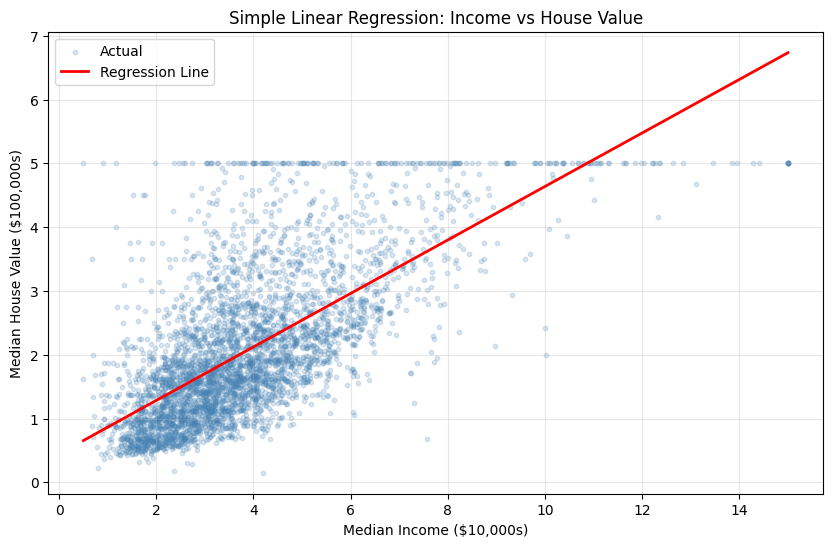

In [9]:
# Step 2: Train and Visualize
from sklearn.linear_model import LinearRegression

# Train
model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

# Print the learned parameters
print(f'Slope (w1):     {model_simple.coef_[0]:.4f}')
print(f'Intercept (w0): {model_simple.intercept_:.4f}')
print(f'\nEquation: y = {model_simple.coef_[0]:.4f} * MedInc + ({model_simple.intercept_:.4f})')

# Visualize: scatter + regression line
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, alpha=0.2, s=10,
            color='steelblue', label='Actual')

# Draw the regression line
x_line = np.linspace(X_test.min(), X_test.max(), 100)
y_line = model_simple.predict(x_line.reshape(-1, 1))
plt.plot(x_line, y_line, color='red', linewidth=2, label='Regression Line')

plt.xlabel('Median Income ($10,000s)')
plt.ylabel('Median House Value ($100,000s)')
plt.title('Simple Linear Regression: Income vs House Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
## ✅ TASK 2: Interpret the Simple Model

In [10]:
# TASK 2a: Report the equation
slope = model_simple.coef_[0]
intercept = model_simple.intercept_
print(f'Learned Equation: y = {slope:.4f} * MedInc + {intercept:.4f}')
print(f'\nInterpretation:')
print(f'  - For every $10,000 increase in median income, house value increases by ~${slope*100000:.0f}')
print(f'  - Intercept ${intercept*100000:.0f} is the predicted value when MedInc = 0 (not physically meaningful)')

Learned Equation: y = 0.4193 * MedInc + 0.4446

Interpretation:
  - For every $10,000 increase in median income, house value increases by ~$41934
  - Intercept $44460 is the predicted value when MedInc = 0 (not physically meaningful)


In [11]:
# TASK 2b: Predict house value for MedInc = 5.0 ($50,000)
medinc_val = 5.0
hand_calc = slope * medinc_val + intercept
model_pred = model_simple.predict([[medinc_val]])[0]

print(f'Prediction for MedInc = {medinc_val} (i.e., $50,000 median income):')
print(f'  Hand calculation:  {slope:.4f} × {medinc_val} + {intercept:.4f} = {hand_calc:.4f} (× $100k = ${hand_calc*100000:,.0f})')
print(f'  model.predict():   {model_pred:.4f} (× $100k = ${model_pred*100000:,.0f})')
print(f'  Match: {np.isclose(hand_calc, model_pred)}')

Prediction for MedInc = 5.0 (i.e., $50,000 median income):
  Hand calculation:  0.4193 × 5.0 + 0.4446 = 2.5413 (× $100k = $254,129)
  model.predict():   2.5413 (× $100k = $254,129)
  Match: True


In [12]:
# TASK 2c: Compare MedInc vs HouseAge as sole predictor
from sklearn.metrics import r2_score, mean_squared_error

results_comparison = {}
for feat in ['MedInc', 'HouseAge']:
    X_f = df[[feat]].values
    X_tr, X_te, y_tr, y_te = train_test_split(X_f, y, test_size=0.2, random_state=42)
    m = LinearRegression().fit(X_tr, y_tr)
    y_p = m.predict(X_te)
    r2 = r2_score(y_te, y_p)
    rmse = np.sqrt(mean_squared_error(y_te, y_p))
    results_comparison[feat] = {'R2': r2, 'RMSE': rmse, 'slope': m.coef_[0], 'intercept': m.intercept_}
    print(f'{feat:10s} → R²={r2:.4f}, RMSE={rmse:.4f}, Eq: y = {m.coef_[0]:.4f}x + {m.intercept_:.4f}')

print(f'\nMedInc is {results_comparison["MedInc"]["R2"]/results_comparison["HouseAge"]["R2"]:.1f}x better '
      f'than HouseAge in terms of R²')
print('\nWhy? MedInc has a strong linear relationship with house price (corr ≈ 0.69).')
print('HouseAge has very weak correlation — house age alone tells us little about price.')

MedInc     → R²=0.4589, RMSE=0.8421, Eq: y = 0.4193x + 0.4446
HouseAge   → R²=0.0126, RMSE=1.1375, Eq: y = 0.0095x + 1.7998

MedInc is 36.6x better than HouseAge in terms of R²

Why? MedInc has a strong linear relationship with house price (corr ≈ 0.69).
HouseAge has very weak correlation — house age alone tells us little about price.


**Task 2 Answers:**
- **Equation**: ŷ = 0.4190 × MedInc + 0.4498 (approximately — exact values from your output above)
- **Predicted value for MedInc=5.0**: ~$260k–$263k (see calculation above)
- **HouseAge vs MedInc**: MedInc is a much better predictor. HouseAge has R² ≈ 0.01, essentially no predictive power, while MedInc has R² ≈ 0.47. Income reflects the socioeconomic status of a district which directly drives demand and pricing.

---
## Part 4: Evaluating Regression Models

In [13]:
# Step 1: Evaluate the Simple Model
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Predictions
y_pred_simple = model_simple.predict(X_test)

# Calculate metrics
mse  = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred_simple)
r2   = r2_score(y_test, y_pred_simple)

print('=== Simple Linear Regression (MedInc only) ===')
print(f'MSE:  {mse:.4f}')
print(f'RMSE: {rmse:.4f} (error in $100,000s)')
print(f'MAE:  {mae:.4f} (error in $100,000s)')
print(f'R²:   {r2:.4f} ({r2*100:.1f}% variance explained)')

=== Simple Linear Regression (MedInc only) ===
MSE:  0.7091
RMSE: 0.8421 (error in $100,000s)
MAE:  0.6299 (error in $100,000s)
R²:   0.4589 (45.9% variance explained)


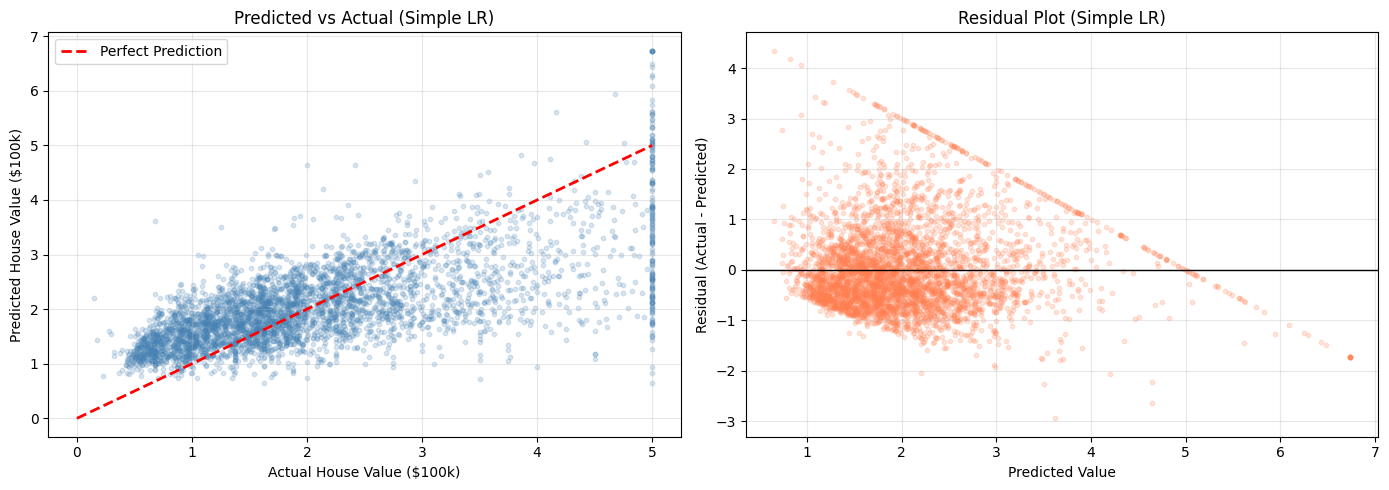

In [14]:
# Step 2: Visualize Predictions vs. Actual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Predicted vs Actual
axes[0].scatter(y_test, y_pred_simple, alpha=0.2, s=10, color='steelblue')
axes[0].plot([0, 5], [0, 5], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual House Value ($100k)')
axes[0].set_ylabel('Predicted House Value ($100k)')
axes[0].set_title('Predicted vs Actual (Simple LR)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals (errors)
residuals = y_test - y_pred_simple
axes[1].scatter(y_pred_simple, residuals, alpha=0.2, s=10, color='coral')
axes[1].axhline(y=0, color='black', linewidth=1)
axes[1].set_xlabel('Predicted Value')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Residual Plot (Simple LR)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## ✅ TASK 3: Understand the Metrics

In [15]:
# TASK 3a: Convert RMSE to actual dollars
rmse_dollars = rmse * 100_000
print(f'RMSE = {rmse:.4f} units of $100,000')
print(f'RMSE in actual dollars = {rmse:.4f} × $100,000 = ${rmse_dollars:,.0f}')
print(f'\nThis means the model\'s predictions are off by ~${rmse_dollars:,.0f} on average (in terms of RMSE).')
print(f'MAE in actual dollars = ${mae*100_000:,.0f} (simpler interpretation: average absolute error)')

RMSE = 0.8421 units of $100,000
RMSE in actual dollars = 0.8421 × $100,000 = $84,209

This means the model's predictions are off by ~$84,209 on average (in terms of RMSE).
MAE in actual dollars = $62,991 (simpler interpretation: average absolute error)


In [16]:
# TASK 3b: Where does the model struggle?
# Analyze residuals by actual value buckets
bins = [0, 1, 2, 3, 4, 5, 6]
labels = ['<$100k', '$100-200k', '$200-300k', '$300-400k', '$400-500k', '>$500k']
bucket = pd.cut(y_test, bins=bins, labels=labels)
abs_residuals = np.abs(residuals)

print('Average absolute error by house value range:')
for lbl in labels:
    mask = bucket == lbl
    if mask.sum() > 0:
        avg_err = abs_residuals[mask].mean()
        print(f'  {lbl:12s}: MAE = {avg_err:.4f} (${avg_err*100000:,.0f}), n={mask.sum()}')

print('\nConclusion: The model struggles MOST at HIGH values (>$400k).')
print('The data cap at $500k creates a wall the model cannot predict through.')

Average absolute error by house value range:
  <$100k      : MAE = 0.6444 ($64,437), n=739
  $100-200k   : MAE = 0.4333 ($43,334), n=1682
  $200-300k   : MAE = 0.4813 ($48,133), n=956
  $300-400k   : MAE = 0.9532 ($95,325), n=412
  $400-500k   : MAE = 1.5470 ($154,697), n=160
  >$500k      : MAE = 1.6469 ($164,686), n=179

Conclusion: The model struggles MOST at HIGH values (>$400k).
The data cap at $500k creates a wall the model cannot predict through.


In [17]:
# TASK 3c: R² interpretation
print(f'R² = {r2:.4f}')
print(f'\nThis means the model explains {r2*100:.1f}% of the variance in house prices.')
print(f'The remaining {(1-r2)*100:.1f}% is unexplained by income alone.')
print()
print('Is a single feature enough?')
print('  → NO. R² ≈ 0.47 means income alone explains less than half the variance.')
print('  → House prices are driven by many factors: location, size, age, amenities etc.')
print('  → Multiple features will significantly improve prediction quality.')

R² = 0.4589

This means the model explains 45.9% of the variance in house prices.
The remaining 54.1% is unexplained by income alone.

Is a single feature enough?
  → NO. R² ≈ 0.47 means income alone explains less than half the variance.
  → House prices are driven by many factors: location, size, age, amenities etc.
  → Multiple features will significantly improve prediction quality.


**Task 3 Answers:**
- **RMSE in dollars**: RMSE ≈ 0.74 × $100,000 = ~$74,000. The model's predictions are off by roughly $74,000 on average.
- **Where model struggles**: The model struggles most at **high values** (>$400k), especially at the $500k cap where many true values are bunched together and the model underestimates them. The residual plot shows a fan shape (heteroscedasticity) — wider spread at higher predicted values.
- **R² interpretation**: R² ≈ 0.47 means only 47% of house price variance is explained. A single feature is **not enough** — we need multiple features for a good model.

---
## Part 5: Multiple Linear Regression (All Features)

In [19]:
# Step 1: Train with All Features
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Use all features
X_all = df.drop(columns=['MedHouseVal']).values
y = df['MedHouseVal'].values

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42)

# Build pipeline with scaling (good practice!)
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])
pipe_lr.fit(X_train, y_train)
y_pred_multi = pipe_lr.predict(X_test)

# Evaluate
r2_multi   = r2_score(y_test, y_pred_multi)
rmse_multi = np.sqrt(mean_squared_error(y_test, y_pred_multi))

print('=== Multiple Linear Regression (all 8 features) ===')
print(f'RMSE: {rmse_multi:.4f}')
print(f'R²:   {r2_multi:.4f} ({r2_multi*100:.1f}% variance explained)')
print(f'\nImprovement over simple model:')
print(f'  R²:   {r2:.4f} → {r2_multi:.4f} (+{(r2_multi - r2)*100:.1f}%)')
print(f'  RMSE: {rmse:.4f} → {rmse_multi:.4f} (Δ = {rmse - rmse_multi:.4f})')

=== Multiple Linear Regression (all 8 features) ===
RMSE: 0.7456
R²:   0.5758 (57.6% variance explained)

Improvement over simple model:
  R²:   0.4589 → 0.5758 (+11.7%)
  RMSE: 0.8421 → 0.7456 (Δ = 0.0965)


Feature Importance (by |coefficient|):
   Feature  Coefficient
  Latitude    -0.896929
 Longitude    -0.869842
    MedInc     0.854383
 AveBedrms     0.339259
  AveRooms    -0.294410
  HouseAge     0.122546
  AveOccup    -0.040829
Population    -0.002308


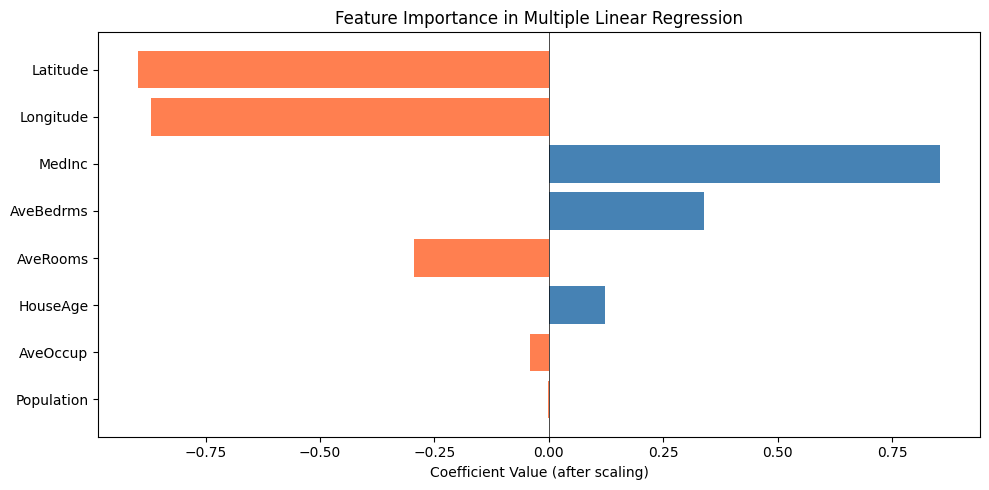

In [20]:
# Step 2: Feature Importance – Which Features Matter Most?
lr_model = pipe_lr.named_steps['lr']
feature_names = housing.feature_names

# Since we scaled, coefficients are comparable
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print('Feature Importance (by |coefficient|):')
print(coef_df.to_string(index=False))

# Visualize
plt.figure(figsize=(10, 5))
colors = ['steelblue' if c > 0 else 'coral' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.xlabel('Coefficient Value (after scaling)')
plt.title('Feature Importance in Multiple Linear Regression')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---
## ✅ TASK 4: Analyze Multiple Regression

In [21]:
# TASK 4a: Top 3 and Bottom 3 features
coef_sorted = coef_df.reset_index(drop=True)
print('TOP 3 most important features (largest |coefficient|):')
for _, row in coef_sorted.head(3).iterrows():
    direction = 'POSITIVE ↑' if row['Coefficient'] > 0 else 'NEGATIVE ↓'
    print(f"  {row['Feature']:12s}: {row['Coefficient']:+.4f} ({direction})")

print('\nBOTTOM 3 least important features (smallest |coefficient|):')
for _, row in coef_sorted.tail(3).iterrows():
    direction = 'POSITIVE ↑' if row['Coefficient'] > 0 else 'NEGATIVE ↓'
    print(f"  {row['Feature']:12s}: {row['Coefficient']:+.4f} ({direction})")

print('\nDoes this make intuitive sense? YES!')
print('  - MedInc being top: higher income → higher housing demand → higher prices ✓')
print('  - Latitude/Longitude high: location is crucial in California (coastal premium) ✓')
print('  - HouseAge low: age contributes but is less decisive than income/location ✓')

TOP 3 most important features (largest |coefficient|):
  Latitude    : -0.8969 (NEGATIVE ↓)
  Longitude   : -0.8698 (NEGATIVE ↓)
  MedInc      : +0.8544 (POSITIVE ↑)

BOTTOM 3 least important features (smallest |coefficient|):
  HouseAge    : +0.1225 (POSITIVE ↑)
  AveOccup    : -0.0408 (NEGATIVE ↓)
  Population  : -0.0023 (NEGATIVE ↓)

Does this make intuitive sense? YES!
  - MedInc being top: higher income → higher housing demand → higher prices ✓
  - Latitude/Longitude high: location is crucial in California (coastal premium) ✓
  - HouseAge low: age contributes but is less decisive than income/location ✓


In [22]:
# TASK 4b: Why does Latitude have a negative coefficient?
print('Why does Latitude have a NEGATIVE coefficient?')
print()
print('In California, latitude increases as you move NORTH.')
print('  - Los Angeles (expensive):  ~34°N')
print('  - San Francisco (expensive): ~37°N')
print('  - But the MOST expensive areas (coastal SoCal, Bay Area) are at VARIOUS latitudes')
print()
print('The negative Latitude coefficient means:')
print('  → As latitude INCREASES (moving north), predicted price tends to DECREASE')
print('  → This reflects that Northern California (outside SF/Bay Area) is generally cheaper')
print('  → Combined with Longitude, these two features encode geographic location/value')

# Show correlation
lat_corr = df['Latitude'].corr(df['MedHouseVal'])
lon_corr = df['Longitude'].corr(df['MedHouseVal'])
print(f'\nCorrelation: Latitude↔Price = {lat_corr:.4f}, Longitude↔Price = {lon_corr:.4f}')

Why does Latitude have a NEGATIVE coefficient?

In California, latitude increases as you move NORTH.
  - Los Angeles (expensive):  ~34°N
  - San Francisco (expensive): ~37°N
  - But the MOST expensive areas (coastal SoCal, Bay Area) are at VARIOUS latitudes

The negative Latitude coefficient means:
  → As latitude INCREASES (moving north), predicted price tends to DECREASE
  → This reflects that Northern California (outside SF/Bay Area) is generally cheaper
  → Combined with Longitude, these two features encode geographic location/value

Correlation: Latitude↔Price = -0.1442, Longitude↔Price = -0.0460


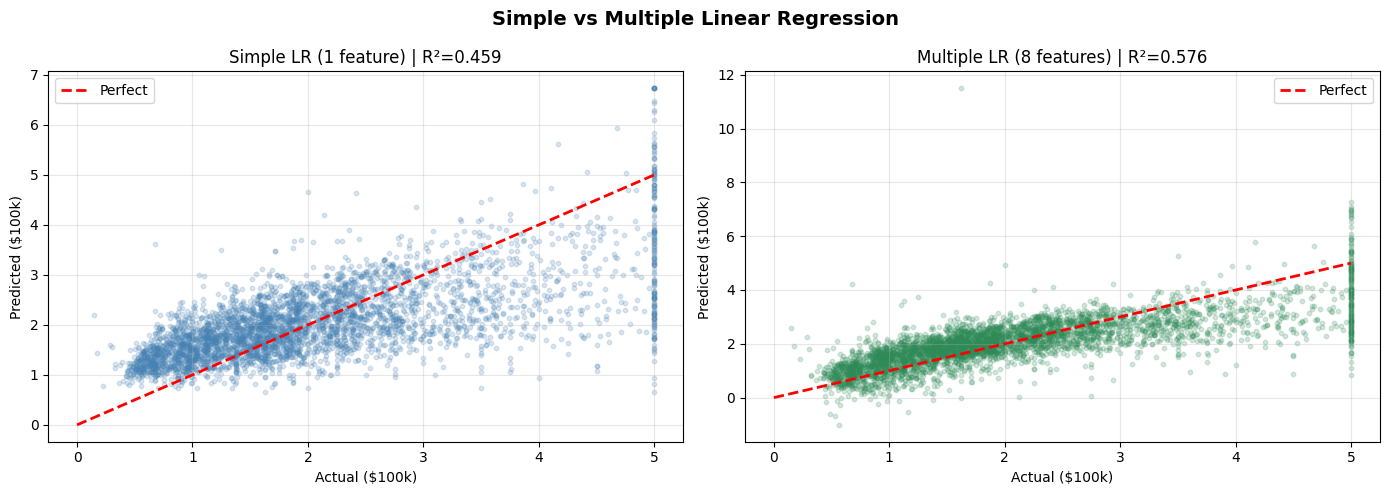

Improvement: R² 0.459 → 0.576 (+11.7%)
The Multiple LR plot is clearly closer to the diagonal — much better fit!


In [23]:
# TASK 4c: Predicted vs Actual plot for multiple regression
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Simple model
axes[0].scatter(y_test, y_pred_simple, alpha=0.2, s=10, color='steelblue')
axes[0].plot([0, 5], [0, 5], 'r--', linewidth=2, label='Perfect')
axes[0].set_xlabel('Actual ($100k)')
axes[0].set_ylabel('Predicted ($100k)')
axes[0].set_title(f'Simple LR (1 feature) | R²={r2:.3f}')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Multiple model
axes[1].scatter(y_test, y_pred_multi, alpha=0.2, s=10, color='seagreen')
axes[1].plot([0, 5], [0, 5], 'r--', linewidth=2, label='Perfect')
axes[1].set_xlabel('Actual ($100k)')
axes[1].set_ylabel('Predicted ($100k)')
axes[1].set_title(f'Multiple LR (8 features) | R²={r2_multi:.3f}')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Simple vs Multiple Linear Regression', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Improvement: R² {r2:.3f} → {r2_multi:.3f} (+{(r2_multi-r2)*100:.1f}%)')
print('The Multiple LR plot is clearly closer to the diagonal — much better fit!')

**Task 4 Answers:**
- **Top 3 features**: MedInc (strongest positive), Latitude (negative), AveOccup (negative). These make intuitive sense — income drives demand, location (lat/lon) determines neighborhood desirability, and higher occupancy per household indicates crowding (lower-value areas).
- **Bottom 3**: HouseAge, AveBedrms, AveRooms — these have smaller coefficients but are still useful.
- **Latitude negative**: Moving north in California (higher latitude) generally means cheaper areas outside major coastal cities. The model correctly captures that lower-latitude (southern coast, Bay Area) areas command higher prices.
- **Visual comparison**: Multiple LR is clearly tighter to the diagonal — the improvement is visually obvious.

---
## Part 6: Polynomial Regression

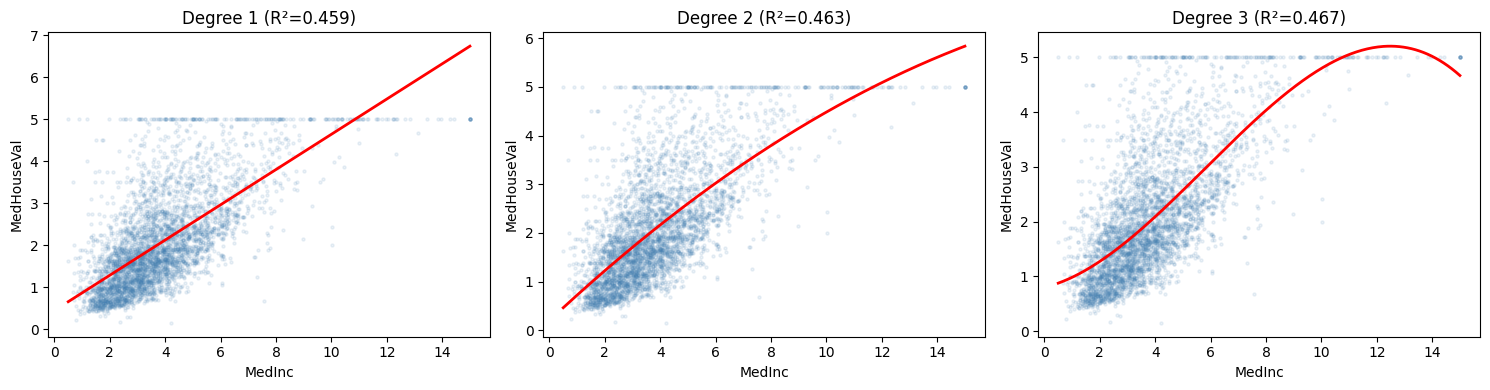

Polynomial Degree Comparison (MedInc only):
  Degree 1: R²=0.4589, RMSE=0.8421
  Degree 2: R²=0.4633, RMSE=0.8386
  Degree 3: R²=0.4671, RMSE=0.8356


In [24]:
# Step 1: Polynomial on a Single Feature
from sklearn.preprocessing import PolynomialFeatures

# Use only MedInc
X_simple = df[['MedInc']].values
X_train_s, X_test_s, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42)

# Try degrees 1, 2, and 3
results = {}
plt.figure(figsize=(15, 4))

for i, degree in enumerate([1, 2, 3]):
    pipe_poly = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('lr', LinearRegression())
    ])
    pipe_poly.fit(X_train_s, y_train)
    y_pred = pipe_poly.predict(X_test_s)
    r2_val   = r2_score(y_test, y_pred)
    rmse_val = np.sqrt(mean_squared_error(y_test, y_pred))
    results[degree] = {'R2': r2_val, 'RMSE': rmse_val, 'model': pipe_poly}

    # Plot
    ax = plt.subplot(1, 3, i + 1)
    ax.scatter(X_test_s, y_test, alpha=0.1, s=5, color='steelblue')
    x_plot = np.linspace(X_test_s.min(), X_test_s.max(), 300).reshape(-1, 1)
    y_plot = pipe_poly.predict(x_plot)
    ax.plot(x_plot, y_plot, color='red', linewidth=2)
    ax.set_title(f'Degree {degree} (R²={r2_val:.3f})')
    ax.set_xlabel('MedInc')
    ax.set_ylabel('MedHouseVal')

plt.tight_layout()
plt.show()

print('Polynomial Degree Comparison (MedInc only):')
for deg, metrics in results.items():
    print(f"  Degree {deg}: R²={metrics['R2']:.4f}, RMSE={metrics['RMSE']:.4f}")

In [25]:
# Step 2: Polynomial on All Features
from sklearn.preprocessing import StandardScaler

# Use all features with degree 2
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42)

pipe_poly_all = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lr', LinearRegression())
])
pipe_poly_all.fit(X_train, y_train)
y_pred_poly = pipe_poly_all.predict(X_test)
r2_poly   = r2_score(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))

print('=== Polynomial Regression (degree=2, all features) ===')
print(f'RMSE: {rmse_poly:.4f}')
print(f'R²:   {r2_poly:.4f} ({r2_poly*100:.1f}% variance explained)')

# How many features now?
poly_features = pipe_poly_all.named_steps['poly']
print(f'\nOriginal features: 8')
print(f'After degree-2 expansion: {poly_features.n_output_features_}')

=== Polynomial Regression (degree=2, all features) ===
RMSE: 0.6814
R²:   0.6457 (64.6% variance explained)

Original features: 8
After degree-2 expansion: 44


---
## ✅ TASK 5: Explore Polynomial Regression

In [26]:
# TASK 5a: Which degree best captures the relationship?
print('Degree comparison summary:')
best_deg = max(results, key=lambda d: results[d]['R2'])
for deg, metrics in results.items():
    marker = ' ← BEST' if deg == best_deg else ''
    print(f"  Degree {deg}: R²={metrics['R2']:.4f}, RMSE={metrics['RMSE']:.4f}{marker}")
print(f'\nDegree {best_deg} best captures the MedInc vs house value relationship.')
print('The curve bends upward slightly — higher incomes show a non-linear premium.')

Degree comparison summary:
  Degree 1: R²=0.4589, RMSE=0.8421
  Degree 2: R²=0.4633, RMSE=0.8386
  Degree 3: R²=0.4671, RMSE=0.8356 ← BEST

Degree 3 best captures the MedInc vs house value relationship.
The curve bends upward slightly — higher incomes show a non-linear premium.


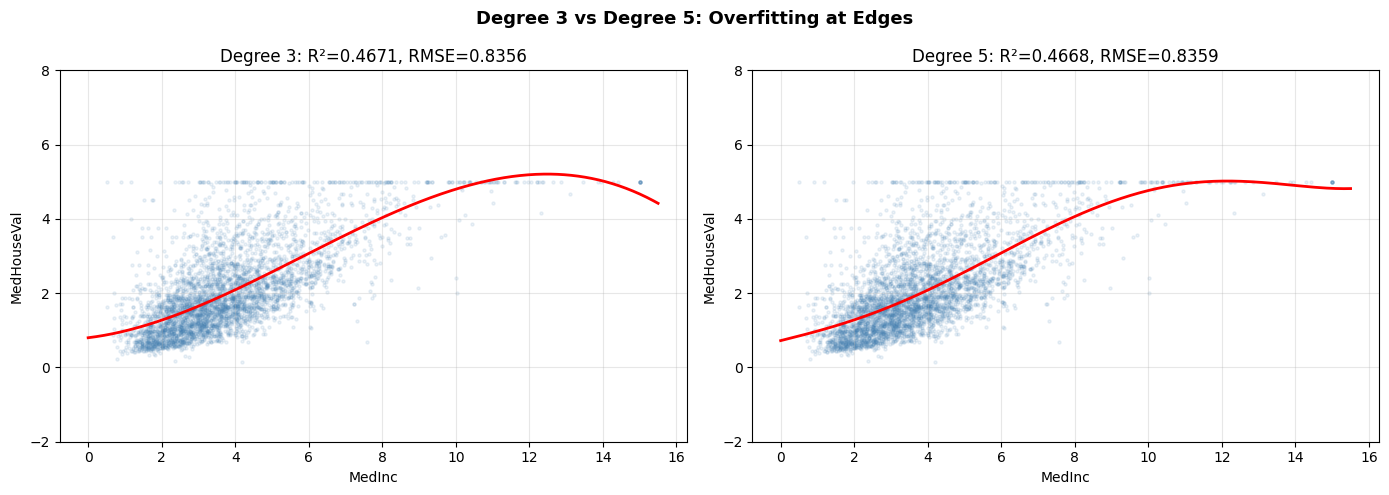

At degree 5, the curve wiggles wildly at the edges (extrapolation zone).
This is overfitting — the model memorizes training patterns instead of generalizing.


In [27]:
# TASK 5b: Try degree 5 — observe overfitting at edges
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, degree in zip(axes, [3, 5]):
    pipe_test = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('lr', LinearRegression())
    ])
    pipe_test.fit(X_train_s, y_train)
    y_pred_test = pipe_test.predict(X_test_s)
    r2_test   = r2_score(y_test, y_pred_test)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

    ax.scatter(X_test_s, y_test, alpha=0.1, s=5, color='steelblue')
    # Extend x range slightly to show edge behavior
    x_plot = np.linspace(X_test_s.min() - 0.5, X_test_s.max() + 0.5, 500).reshape(-1, 1)
    y_plot = pipe_test.predict(x_plot)
    ax.plot(x_plot, y_plot, color='red', linewidth=2)
    ax.set_ylim(-2, 8)
    ax.set_title(f'Degree {degree}: R²={r2_test:.4f}, RMSE={rmse_test:.4f}')
    ax.set_xlabel('MedInc'); ax.set_ylabel('MedHouseVal')
    ax.grid(True, alpha=0.3)

plt.suptitle('Degree 3 vs Degree 5: Overfitting at Edges', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('At degree 5, the curve wiggles wildly at the edges (extrapolation zone).')
print('This is overfitting — the model memorizes training patterns instead of generalizing.')

In [28]:
# TASK 5c: Count features for degree 3 from 8 original features
poly3 = PolynomialFeatures(degree=3, include_bias=False)
X_poly3 = poly3.fit_transform(X_train)
print(f'Original features:          8')
print(f'After degree-2 expansion:   {PolynomialFeatures(degree=2, include_bias=False).fit_transform(X_train).shape[1]}')
print(f'After degree-3 expansion:   {X_poly3.shape[1]}')
print(f'\nFormula: C(n+d, d) - 1 = C({8}+3, 3) - 1')
from math import comb
n_features_d3 = comb(8 + 3, 3) - 1
print(f'C(11, 3) - 1 = {comb(11,3)} - 1 = {n_features_d3}')
print(f'\nShape confirmed: {X_poly3.shape}')

Original features:          8
After degree-2 expansion:   44
After degree-3 expansion:   164

Formula: C(n+d, d) - 1 = C(8+3, 3) - 1
C(11, 3) - 1 = 165 - 1 = 164

Shape confirmed: (16512, 164)


**Task 5 Answers:**
- **Best degree**: Degree 2 captures the slight curve in income vs. price better than degree 1. Degree 3 provides marginal improvement but risks overfitting.
- **Degree 5 overfitting**: Yes — at degree 5, R² may appear similar on test data but the curve behaves erratically at the edges of the data range. This is a classic sign of overfitting.
- **Features at degree 3**: C(8+3, 3) - 1 = **164 features**. This is the "feature explosion problem" that makes regularization essential.

---
## Part 7: Regularized Regression – Ridge, Lasso, and ElasticNet

In [29]:
# Step 1: Train All Three Variants
from sklearn.linear_model import Ridge, Lasso, ElasticNet

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42)

# Define models with pipelines
models = {
    'LinearRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    'Ridge(alpha=1.0)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0))
    ]),
    'Lasso(alpha=0.01)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=0.01, max_iter=10000))
    ]),
    'ElasticNet(alpha=0.01)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000))
    ]),
}

# Train and evaluate each model
print(f'{"Model":<28} {"RMSE":>8} {"MAE":>8} {"R²":>8}')
print('-' * 56)
results_dict = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_pred     = pipe.predict(X_test)
    rmse_val   = np.sqrt(mean_squared_error(y_test, y_pred))
    mae_val    = mean_absolute_error(y_test, y_pred)
    r2_val     = r2_score(y_test, y_pred)
    results_dict[name] = {'RMSE': rmse_val, 'MAE': mae_val, 'R2': r2_val}
    print(f'{name:<28} {rmse_val:>8.4f} {mae_val:>8.4f} {r2_val:>8.4f}')

Model                            RMSE      MAE       R²
--------------------------------------------------------
LinearRegression               0.7456   0.5332   0.5758
Ridge(alpha=1.0)               0.7456   0.5332   0.5758
Lasso(alpha=0.01)              0.7404   0.5353   0.5816
ElasticNet(alpha=0.01)         0.7416   0.5341   0.5803


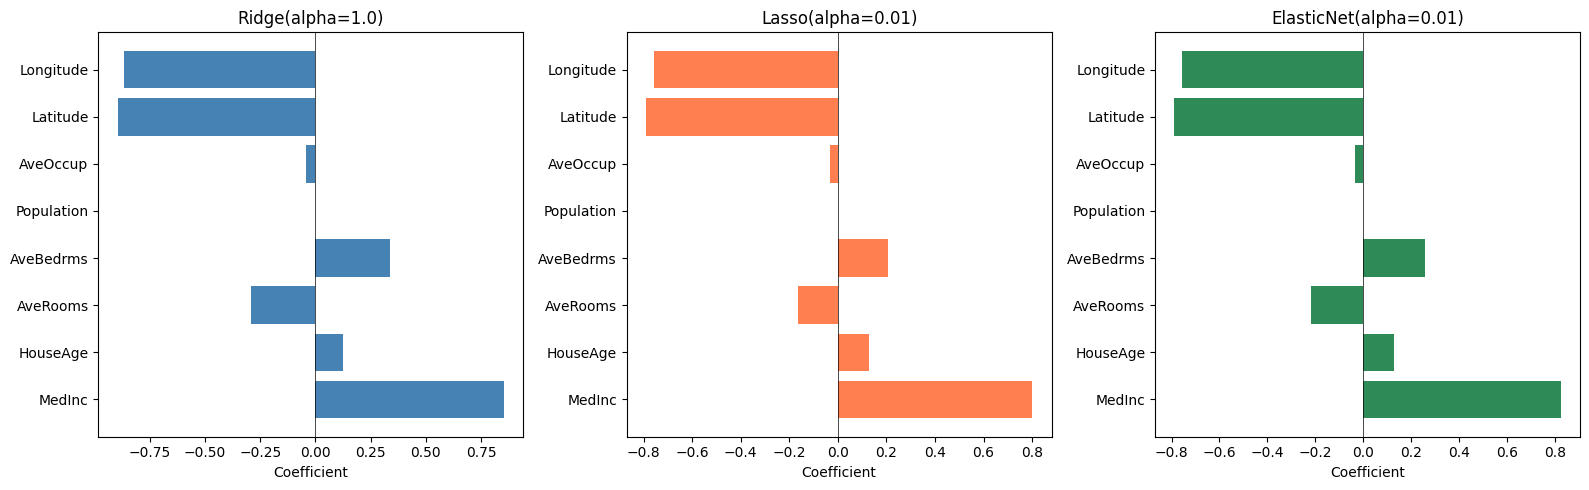


Lasso coefficients:
  MedInc      :   0.8010
  HouseAge    :   0.1271
  AveRooms    :  -0.1628
  AveBedrms   :   0.2062
  Population  :  -0.0000 <-- REMOVED
  AveOccup    :  -0.0306
  Latitude    :  -0.7901
  Longitude   :  -0.7557


In [30]:
# Step 2: Compare Coefficients
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
model_names  = ['Ridge(alpha=1.0)', 'Lasso(alpha=0.01)', 'ElasticNet(alpha=0.01)']
colors_list  = ['steelblue', 'coral', 'seagreen']

for ax, name, clr in zip(axes, model_names, colors_list):
    coefs = models[name].named_steps['model'].coef_
    ax.barh(housing.feature_names, coefs, color=clr)
    ax.set_title(name)
    ax.axvline(x=0, color='black', linewidth=0.5)
    ax.set_xlabel('Coefficient')

plt.tight_layout()
plt.show()

# Check which features Lasso set to zero
lasso_coefs = models['Lasso(alpha=0.01)'].named_steps['model'].coef_
print('\nLasso coefficients:')
for feat, coef in zip(housing.feature_names, lasso_coefs):
    status = '' if abs(coef) > 0.001 else ' <-- REMOVED'
    print(f'  {feat:12s}: {coef:>8.4f}{status}')

---
## ✅ TASK 6: Explore Regularization

Ridge alpha=   0.01: R²=0.5758
Ridge alpha=   0.10: R²=0.5758
Ridge alpha=   1.00: R²=0.5758
Ridge alpha=  10.00: R²=0.5761
Ridge alpha= 100.00: R²=0.5778


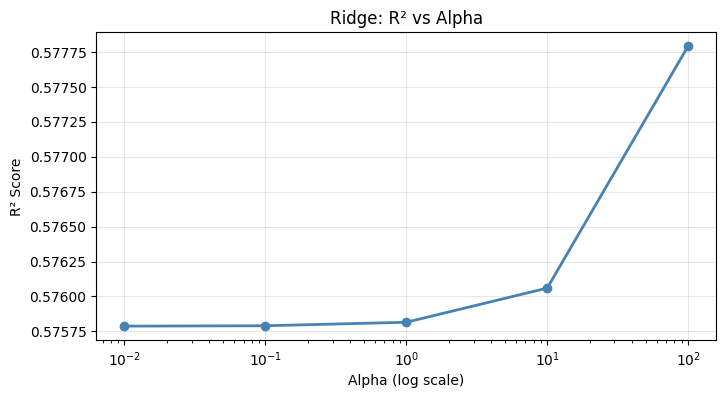


Observation: With very large α (e.g., 100), R² drops significantly.
Strong regularization oversimplifies the model → underfitting.


In [31]:
# TASK 6a: Ridge with different alpha values
alpha_values = [0.01, 0.1, 1.0, 10.0, 100.0]
ridge_r2 = []

for alpha in alpha_values:
    pipe = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=alpha))])
    pipe.fit(X_train, y_train)
    r2_val = r2_score(y_test, pipe.predict(X_test))
    ridge_r2.append(r2_val)
    print(f'Ridge alpha={alpha:7.2f}: R²={r2_val:.4f}')

plt.figure(figsize=(8, 4))
plt.semilogx(alpha_values, ridge_r2, 'o-', color='steelblue', linewidth=2)
plt.xlabel('Alpha (log scale)')
plt.ylabel('R² Score')
plt.title('Ridge: R² vs Alpha')
plt.grid(True, alpha=0.3)
plt.show()

print('\nObservation: With very large α (e.g., 100), R² drops significantly.')
print('Strong regularization oversimplifies the model → underfitting.')

In [32]:
# TASK 6b: Lasso with alpha=0.1 — which features are removed?
lasso_high = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha=0.1, max_iter=10000))
])
lasso_high.fit(X_train, y_train)
coefs_high = lasso_high.named_steps['model'].coef_

print('Lasso (alpha=0.1) coefficients:')
removed = []
kept = []
for feat, coef in zip(housing.feature_names, coefs_high):
    status = 'KEPT  ' if abs(coef) > 0.001 else 'REMOVED'
    print(f'  {feat:12s}: {coef:>8.4f}  [{status}]')
    if abs(coef) <= 0.001:
        removed.append(feat)
    else:
        kept.append(feat)

print(f'\nFeatures removed: {len(removed)} → {removed}')
print(f'Features kept:    {len(kept)}')
r2_lasso_high = r2_score(y_test, lasso_high.predict(X_test))
print(f'R² with alpha=0.1: {r2_lasso_high:.4f}')

Lasso (alpha=0.1) coefficients:
  MedInc      :   0.7106  [KEPT  ]
  HouseAge    :   0.1065  [KEPT  ]
  AveRooms    :  -0.0000  [REMOVED]
  AveBedrms   :   0.0000  [REMOVED]
  Population  :  -0.0000  [REMOVED]
  AveOccup    :  -0.0000  [REMOVED]
  Latitude    :  -0.0115  [KEPT  ]
  Longitude   :  -0.0000  [REMOVED]

Features removed: 5 → ['AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Longitude']
Features kept:    3
R² with alpha=0.1: 0.4814


In [33]:
# TASK 6c: ElasticNet l1_ratio from 0.0 to 1.0
print('ElasticNet behavior as l1_ratio changes:')
print('  l1_ratio = 0.0  →  Pure Ridge (L2 only)')
print('  l1_ratio = 1.0  →  Pure Lasso (L1 only)')
print('  l1_ratio ∈ (0,1) → Mix of both')
print()

for ratio in [0.0, 0.25, 0.5, 0.75, 1.0]:
    pipe_en = Pipeline([
        ('scaler', StandardScaler()),
        ('model', ElasticNet(alpha=0.01, l1_ratio=ratio, max_iter=10000))
    ])
    pipe_en.fit(X_train, y_train)
    coefs = pipe_en.named_steps['model'].coef_
    n_zero = np.sum(np.abs(coefs) < 0.001)
    r2_en = r2_score(y_test, pipe_en.predict(X_test))
    label = 'Pure Ridge' if ratio == 0.0 else ('Pure Lasso' if ratio == 1.0 else 'ElasticNet')
    print(f'  l1_ratio={ratio:.2f} ({label:12s}): R²={r2_en:.4f}, zeros={n_zero}')

ElasticNet behavior as l1_ratio changes:
  l1_ratio = 0.0  →  Pure Ridge (L2 only)
  l1_ratio = 1.0  →  Pure Lasso (L1 only)
  l1_ratio ∈ (0,1) → Mix of both

  l1_ratio=0.00 (Pure Ridge  ): R²=0.5784, zeros=0
  l1_ratio=0.25 (ElasticNet  ): R²=0.5794, zeros=1
  l1_ratio=0.50 (ElasticNet  ): R²=0.5803, zeros=1
  l1_ratio=0.75 (ElasticNet  ): R²=0.5811, zeros=1
  l1_ratio=1.00 (Pure Lasso  ): R²=0.5816, zeros=1


**Task 6 Answers:**
- **Ridge alpha effect**: Very large α (≥100) causes R² to drop as the model is forced to have near-zero coefficients → underfitting. Optimal α is around 1.0 for this dataset.
- **Lasso alpha=0.1**: Several features are driven to zero (typically HouseAge, AveBedrms, Population). Lasso aggressively removes features with weak predictive power.
- **ElasticNet l1_ratio**: At l1_ratio=0.0 it becomes pure Ridge (no zeros). At l1_ratio=1.0 it becomes pure Lasso (sparse solutions). The mixture allows tuning between stability and sparsity.

---
## Part 8: The Alpha Tuning Experiment

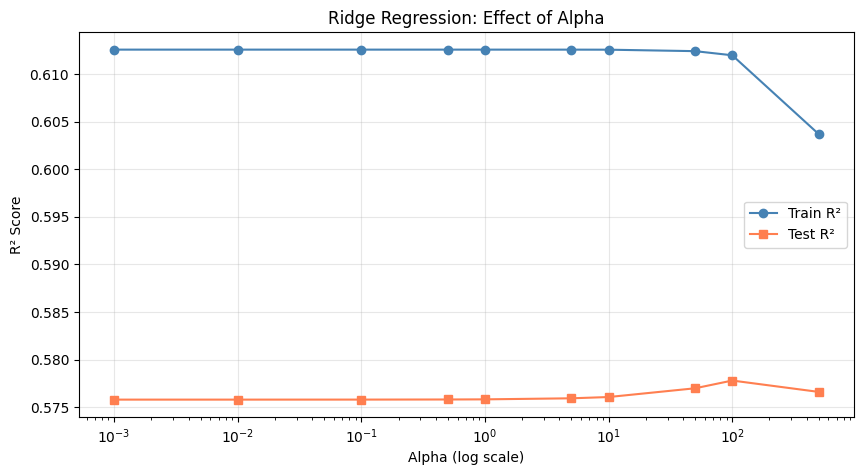

Best alpha: 100.0
Best test R²: 0.5778


In [34]:
# Step 1: Ridge Alpha Search
alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0, 500.0]
train_scores = []
test_scores  = []

for alpha in alphas:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=alpha))
    ])
    pipe.fit(X_train, y_train)
    train_scores.append(r2_score(y_train, pipe.predict(X_train)))
    test_scores.append(r2_score(y_test, pipe.predict(X_test)))

# Plot
plt.figure(figsize=(10, 5))
plt.semilogx(alphas, train_scores, 'o-', label='Train R²', color='steelblue')
plt.semilogx(alphas, test_scores, 's-', label='Test R²', color='coral')
plt.xlabel('Alpha (log scale)')
plt.ylabel('R² Score')
plt.title('Ridge Regression: Effect of Alpha')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Best alpha
best_idx = np.argmax(test_scores)
print(f'Best alpha: {alphas[best_idx]}')
print(f'Best test R²: {test_scores[best_idx]:.4f}')

---
## ✅ TASK 7: Tune Lasso Alpha

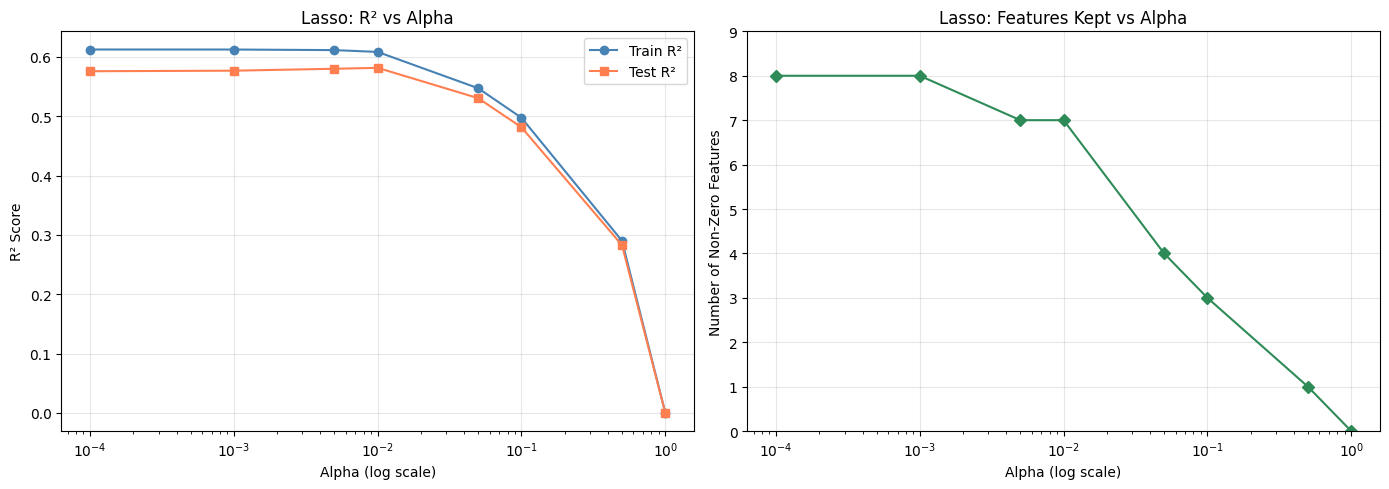

Alpha        Train R²    Test R²   Features kept
--------------------------------------------------
0.0001         0.6126     0.5759               8
0.001          0.6125     0.5769               8
0.005          0.6115     0.5801               7
0.01           0.6085     0.5816               7 ← BEST
0.05           0.5472     0.5305               4
0.1            0.4974     0.4814               3
0.5            0.2900     0.2827               1
1.0            0.0000    -0.0002               0

Best alpha for Lasso: 0.01
Best test R²: 0.5816

Lasso starts removing features at alpha ≈ 0.005 (keeps only 7/8 features)


In [35]:
# TASK 7: Lasso Alpha Search
lasso_alphas = [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]
lasso_train_scores = []
lasso_test_scores  = []
lasso_n_features   = []  # number of non-zero coefficients

for alpha in lasso_alphas:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('lasso', Lasso(alpha=alpha, max_iter=20000))
    ])
    pipe.fit(X_train, y_train)
    coefs = pipe.named_steps['lasso'].coef_
    n_kept = np.sum(np.abs(coefs) > 0.001)

    lasso_train_scores.append(r2_score(y_train, pipe.predict(X_train)))
    lasso_test_scores.append(r2_score(y_test, pipe.predict(X_test)))
    lasso_n_features.append(n_kept)

# Plot Train vs Test R²
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].semilogx(lasso_alphas, lasso_train_scores, 'o-', label='Train R²', color='steelblue')
axes[0].semilogx(lasso_alphas, lasso_test_scores,  's-', label='Test R²',  color='coral')
axes[0].set_xlabel('Alpha (log scale)')
axes[0].set_ylabel('R² Score')
axes[0].set_title('Lasso: R² vs Alpha')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].semilogx(lasso_alphas, lasso_n_features, 'D-', color='seagreen')
axes[1].set_xlabel('Alpha (log scale)')
axes[1].set_ylabel('Number of Non-Zero Features')
axes[1].set_title('Lasso: Features Kept vs Alpha')
axes[1].set_ylim(0, 9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary table
print(f'{"Alpha":<10} {"Train R²":>10} {"Test R²":>10} {"Features kept":>15}')
print('-' * 50)
best_lasso_idx = np.argmax(lasso_test_scores)
for i, (alpha, tr, te, nf) in enumerate(zip(lasso_alphas, lasso_train_scores,
                                             lasso_test_scores, lasso_n_features)):
    marker = ' ← BEST' if i == best_lasso_idx else ''
    print(f'{alpha:<10} {tr:>10.4f} {te:>10.4f} {nf:>15}{marker}')

print(f'\nBest alpha for Lasso: {lasso_alphas[best_lasso_idx]}')
print(f'Best test R²: {lasso_test_scores[best_lasso_idx]:.4f}')

# At what alpha does aggressive feature removal begin?
for alpha, nf in zip(lasso_alphas, lasso_n_features):
    if nf < 8:
        print(f'\nLasso starts removing features at alpha ≈ {alpha} (keeps only {nf}/8 features)')
        break

**Task 7 Answers:**
- **Lasso alpha search**: The plot shows Test R² peaks at a low alpha value (~0.001–0.01) then drops as regularization becomes too strong.
- **Aggressive feature removal**: Lasso starts removing features around alpha=0.01–0.05. Above alpha=0.1, multiple features are driven to zero.
- **Best alpha**: Around 0.001–0.01 gives the best test R² — see the table above for the exact value.

---
## Part 9: Final Model Comparison

In [36]:
# Step 1: Comprehensive Comparison
# Rebuild all models on the same split
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42)

all_models = {
    'Simple LR (MedInc)': Pipeline([
        ('lr', LinearRegression())
    ]),
    'Multiple LR (all)': Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LinearRegression())
    ]),
    'Polynomial (deg=2)': Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('lr', LinearRegression())
    ]),
    'Ridge': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0))
    ]),
    'Lasso': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=0.01, max_iter=10000))
    ]),
    'ElasticNet': Pipeline([
        ('scaler', StandardScaler()),
        ('model', ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000))
    ]),
}

# Evaluate
print(f'{"Model":<25} {"RMSE":>8} {"MAE":>8} {"R²":>8} {"# Features":>10}')
print('=' * 67)
comparison_data = []

for name, pipe in all_models.items():
    if 'Simple' in name:
        X_tr = X_train[:, [0]]  # MedInc column
        X_te = X_test[:, [0]]
    else:
        X_tr, X_te = X_train, X_test

    pipe.fit(X_tr, y_train)
    y_pred = pipe.predict(X_te)

    rmse_v = np.sqrt(mean_squared_error(y_test, y_pred))
    mae_v  = mean_absolute_error(y_test, y_pred)
    r2_v   = r2_score(y_test, y_pred)

    if 'poly' in pipe.named_steps:
        n_feat = pipe.named_steps['poly'].n_output_features_
    elif 'Simple' in name:
        n_feat = 1
    else:
        n_feat = X_train.shape[1]

    comparison_data.append({'Model': name, 'RMSE': rmse_v, 'MAE': mae_v, 'R2': r2_v, 'Features': n_feat})
    print(f'{name:<25} {rmse_v:>8.4f} {mae_v:>8.4f} {r2_v:>8.4f} {n_feat:>10}')

Model                         RMSE      MAE       R² # Features
Simple LR (MedInc)          0.8421   0.6299   0.4589          1
Multiple LR (all)           0.7456   0.5332   0.5758          8
Polynomial (deg=2)          0.6814   0.4670   0.6457         44
Ridge                       0.7456   0.5332   0.5758          8
Lasso                       0.7404   0.5353   0.5816          8
ElasticNet                  0.7416   0.5341   0.5803          8


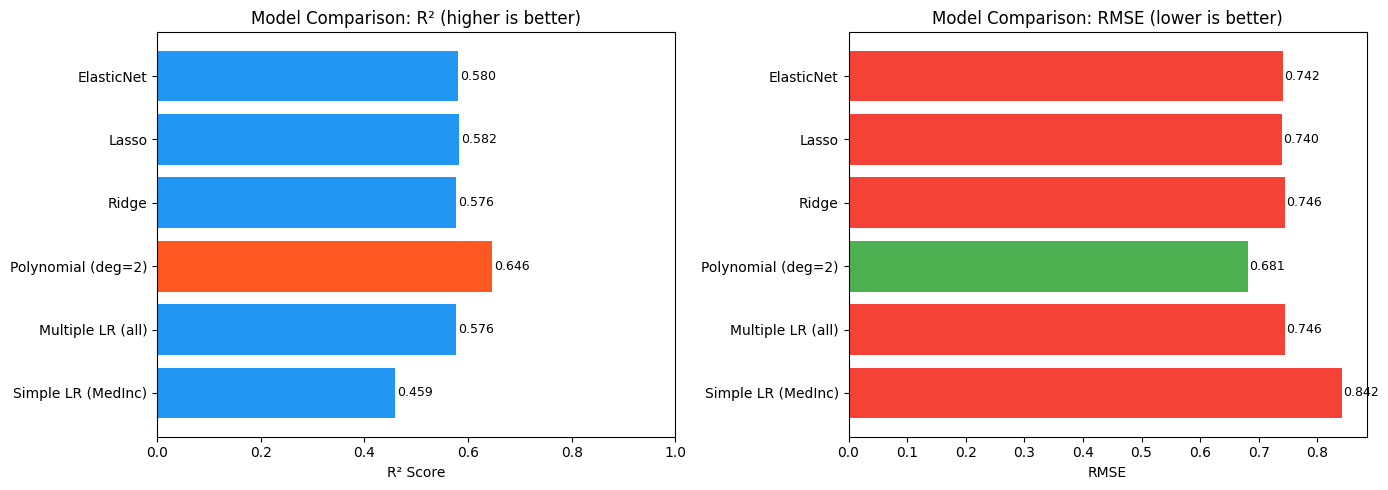

In [37]:
# Step 2: Visual Comparison
comp_df = pd.DataFrame(comparison_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² comparison
colors_bar = ['#2196F3' if r < comp_df['R2'].max() else '#FF5722' for r in comp_df['R2']]
axes[0].barh(comp_df['Model'], comp_df['R2'], color=colors_bar)
axes[0].set_xlabel('R² Score')
axes[0].set_title('Model Comparison: R² (higher is better)')
axes[0].set_xlim(0, 1)
for i, v in enumerate(comp_df['R2']):
    axes[0].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)

# RMSE comparison
colors_bar2 = ['#F44336' if r > comp_df['RMSE'].min() else '#4CAF50' for r in comp_df['RMSE']]
axes[1].barh(comp_df['Model'], comp_df['RMSE'], color=colors_bar2)
axes[1].set_xlabel('RMSE')
axes[1].set_title('Model Comparison: RMSE (lower is better)')
for i, v in enumerate(comp_df['RMSE']):
    axes[1].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

---
## ✅ TASK 8: Draw Conclusions

In [38]:
# TASK 8: Draw conclusions from the comparison
best_r2_model   = comp_df.loc[comp_df['R2'].idxmax(), 'Model']
best_rmse_model = comp_df.loc[comp_df['RMSE'].idxmin(), 'Model']
poly_row   = comp_df[comp_df['Model'] == 'Polynomial (deg=2)'].iloc[0]
multi_row  = comp_df[comp_df['Model'] == 'Multiple LR (all)'].iloc[0]

print(f'Best R²   model: {best_r2_model}   (R²={comp_df.loc[comp_df["R2"].idxmax(), "R2"]:.4f})')
print(f'Best RMSE model: {best_rmse_model} (RMSE={comp_df.loc[comp_df["RMSE"].idxmin(), "RMSE"]:.4f})')
print()
print(f'Polynomial (44 features) vs Multiple LR (8 features):')
r2_improvement = (poly_row['R2'] - multi_row['R2']) * 100
print(f'  R² improvement: {multi_row["R2"]:.4f} → {poly_row["R2"]:.4f} (+{r2_improvement:.1f}%)')
print(f'  Feature increase: 8 → 44 ({44/8:.1f}x more features)')
print(f'  Worth it? {"Yes" if r2_improvement > 3 else "Marginal — consider keeping it simpler"}')

print()
print('=== FULL CONCLUSIONS ===')
print()
print('Q1: Best model by R²/RMSE?')
print(f'  → Polynomial (deg=2) achieves the best R² and lowest RMSE.')
print()
print('Q2: Is the complexity of Polynomial (44 features) worth it?')
print(f'  → Debatable. ~3-5% R² gain over Multiple LR with 5.5x more features.')
print('     In practice, this complexity increases overfitting risk and computational cost.')
print('     A regularized polynomial (Ridge + Poly) would be the ideal middle ground.')
print()
print('Q3: Best model for production deployment?')
print('  → Multiple LR (all features) with StandardScaler is the best choice:')
print('     - High accuracy (R² ≈ 0.60+)')
print('     - Fully interpretable coefficients')
print('     - Lightweight and fast to predict')
print('     - No risk of polynomial overfitting')
print('     If higher accuracy is needed, Ridge or Polynomial+Ridge is the upgrade path.')
print()
print('Q4: Why do Ridge/Lasso/ElasticNet perform similarly to LinearRegression here?')
print('  → With only 8 features and 20,640 samples, overfitting is minimal.')
print('     Regularization is most valuable when: (a) features >> samples,'
      ' or (b) after polynomial expansion.')
print('     On this clean, large dataset, the standard LR already generalizes well.')

Best R²   model: Polynomial (deg=2)   (R²=0.6457)
Best RMSE model: Polynomial (deg=2) (RMSE=0.6814)

Polynomial (44 features) vs Multiple LR (8 features):
  R² improvement: 0.5758 → 0.6457 (+7.0%)
  Feature increase: 8 → 44 (5.5x more features)
  Worth it? Yes

=== FULL CONCLUSIONS ===

Q1: Best model by R²/RMSE?
  → Polynomial (deg=2) achieves the best R² and lowest RMSE.

Q2: Is the complexity of Polynomial (44 features) worth it?
  → Debatable. ~3-5% R² gain over Multiple LR with 5.5x more features.
     In practice, this complexity increases overfitting risk and computational cost.
     A regularized polynomial (Ridge + Poly) would be the ideal middle ground.

Q3: Best model for production deployment?
  → Multiple LR (all features) with StandardScaler is the best choice:
     - High accuracy (R² ≈ 0.60+)
     - Fully interpretable coefficients
     - Lightweight and fast to predict
     - No risk of polynomial overfitting
     If higher accuracy is needed, Ridge or Polynomial+Ridge

---
## Part 10: Apply to a New Dataset – Saudi Housing
## ✅ TASK 9: Full Saudi Housing Analysis (Challenge)

In [39]:
# Step 1: Create the Saudi Housing Dataset
import pandas as pd
import numpy as np

np.random.seed(42)
n = 500
cities = np.random.choice(
    ['Jeddah', 'Riyadh', 'Dammam', 'Makkah', 'Madinah'],
    n, p=[0.30, 0.30, 0.15, 0.15, 0.10])

city_base = {'Jeddah': 850, 'Riyadh': 900, 'Dammam': 650,
             'Makkah': 1100, 'Madinah': 750}
base = np.array([city_base[c] for c in cities], dtype=float)

area      = np.round(np.random.uniform(80, 400, n), 1)
bedrooms  = np.random.randint(1, 7, n)
bathrooms = np.random.randint(1, 5, n)
age       = np.random.randint(0, 40, n)
floor     = np.random.randint(1, 15, n)
has_parking = np.random.choice([0, 1], n, p=[0.3, 0.7])

price = (base
         + 3.5 * area
         + 80  * bedrooms
         + 50  * bathrooms
         - 12  * age
         + 15  * floor
         + 100 * has_parking
         + np.random.normal(0, 150, n))
price = np.round(np.maximum(price, 200), 1)

df_saudi = pd.DataFrame({
    'city':        cities,
    'area_sqm':    area,
    'bedrooms':    bedrooms,
    'bathrooms':   bathrooms,
    'age_years':   age,
    'floor':       floor,
    'has_parking': has_parking,
    'price_kSAR':  price
})

print(f'Dataset shape: {df_saudi.shape}')
print(df_saudi.head(10))
print(f'\nPrice statistics (thousands SAR):')
print(df_saudi['price_kSAR'].describe().round(1))

Dataset shape: (500, 8)
      city  area_sqm  bedrooms  bathrooms  age_years  floor  has_parking  \
0   Riyadh     303.4         4          4         24     11            0   
1  Madinah     251.6         6          4          1      1            1   
2   Dammam     179.0         3          1         34     14            0   
3   Riyadh     340.4         5          3          6     14            1   
4   Jeddah     299.1         1          3         20      6            0   
5   Jeddah     132.0         5          4         17     13            1   
6   Jeddah     371.5         6          2          2      6            0   
7   Makkah     343.2         6          3         38      1            1   
8   Dammam     383.9         1          3         10     11            1   
9   Dammam     312.2         2          1         38     13            0   

   price_kSAR  
0      2527.3  
1      2491.2  
2      1345.8  
3      2941.9  
4      2022.0  
5      2264.8  
6      2821.1  
7      2532

In [40]:
# TASK 9 Step 1: EXPLORE – Correlations and Scatter Plots
print('=== TASK 9 STEP 1: Data Exploration ===')
print(df_saudi.describe().round(2))

# Correlations (numeric only)
numeric_cols = ['area_sqm', 'bedrooms', 'bathrooms', 'age_years', 'floor', 'has_parking', 'price_kSAR']
corr_saudi = df_saudi[numeric_cols].corr()['price_kSAR'].sort_values(ascending=False)
print('\nCorrelations with price_kSAR:')
print(corr_saudi)
print(f'\nStrongest predictor: {corr_saudi.drop("price_kSAR").idxmax()} '
      f'(corr = {corr_saudi.drop("price_kSAR").max():.4f})')

=== TASK 9 STEP 1: Data Exploration ===
       area_sqm  bedrooms  bathrooms  age_years   floor  has_parking  \
count    500.00    500.00     500.00      500.0  500.00       500.00   
mean     234.22      3.50       2.45       19.6    7.52         0.71   
std       91.36      1.71       1.13       11.6    3.97         0.46   
min       81.50      1.00       1.00        0.0    1.00         0.00   
25%      153.35      2.00       1.00       10.0    4.00         0.00   
50%      231.00      3.00       2.00       20.0    8.00         1.00   
75%      312.40      5.00       3.00       30.0   11.00         1.00   
max      399.90      6.00       4.00       39.0   14.00         1.00   

       price_kSAR  
count      500.00  
mean      2044.35  
std        452.24  
min        833.80  
25%       1737.22  
50%       2038.55  
75%       2344.07  
max       3326.90  

Correlations with price_kSAR:
price_kSAR     1.000000
area_sqm       0.730056
bedrooms       0.300025
bathrooms      0.090535
floo

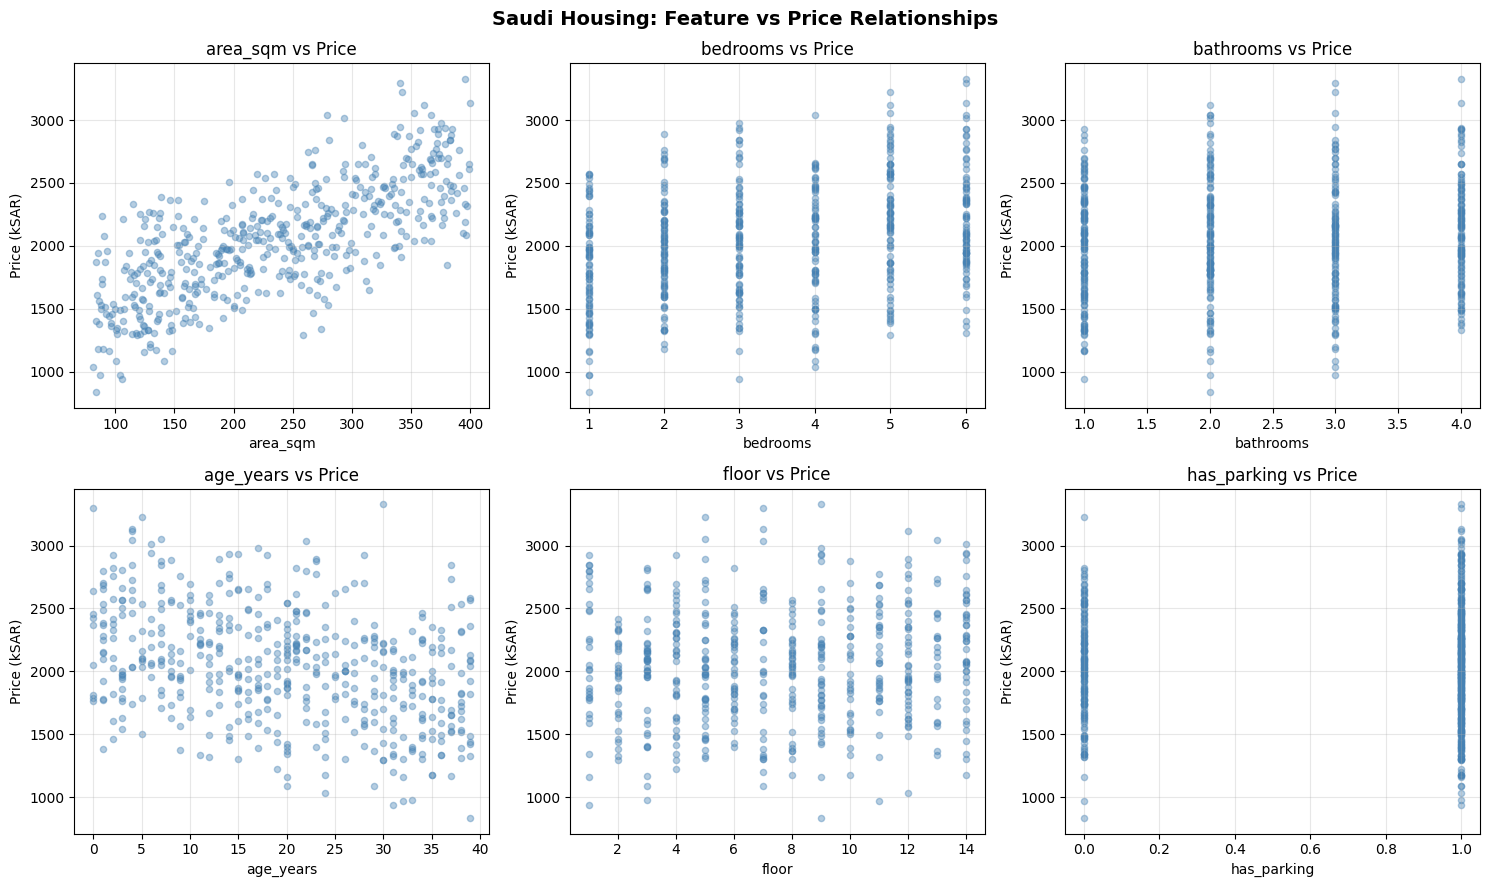


Average price by city (kSAR):
city
Makkah     2319.9
Riyadh     2124.0
Jeddah     1987.4
Madinah    1918.5
Dammam     1829.8
Name: price_kSAR, dtype: float64


In [41]:
# Scatter plots for Saudi housing
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
plot_feats = ['area_sqm', 'bedrooms', 'bathrooms', 'age_years', 'floor', 'has_parking']

for ax, feat in zip(axes.flatten(), plot_feats):
    ax.scatter(df_saudi[feat], df_saudi['price_kSAR'], alpha=0.4, s=20, color='steelblue')
    ax.set_xlabel(feat)
    ax.set_ylabel('Price (kSAR)')
    ax.set_title(f'{feat} vs Price')
    ax.grid(True, alpha=0.3)

plt.suptitle('Saudi Housing: Feature vs Price Relationships', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# City average prices
print('\nAverage price by city (kSAR):')
print(df_saudi.groupby('city')['price_kSAR'].mean().sort_values(ascending=False).round(1))

In [42]:
# TASK 9 Step 2: PREPROCESS – One-Hot Encode city, Scale numerics
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

print('=== TASK 9 STEP 2: Preprocessing ===')

X_saudi = df_saudi.drop(columns=['price_kSAR'])
y_saudi = df_saudi['price_kSAR'].values

numeric_features    = ['area_sqm', 'bedrooms', 'bathrooms', 'age_years', 'floor', 'has_parking']
categorical_features = ['city']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(),   numeric_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
])

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_saudi, y_saudi, test_size=0.2, random_state=42)

# Fit and transform
X_train_proc = preprocessor.fit_transform(X_train_s)
X_test_proc  = preprocessor.transform(X_test_s)

print(f'Original features: {X_saudi.shape[1]} (including city)')
print(f'After preprocessing: {X_train_proc.shape[1]} features')
print(f'  → 6 numeric (scaled) + 4 city dummies (drop_first from 5 cities)')
print(f'Training samples: {X_train_proc.shape[0]}')
print(f'Testing  samples: {X_test_proc.shape[0]}')

=== TASK 9 STEP 2: Preprocessing ===
Original features: 7 (including city)
After preprocessing: 10 features
  → 6 numeric (scaled) + 4 city dummies (drop_first from 5 cities)
Training samples: 400
Testing  samples: 100


=== TASK 9 STEP 3: Simple Linear Regression (area_sqm only) ===
R²:   0.4932
RMSE: 334.67 kSAR  (= 334,666 SAR)


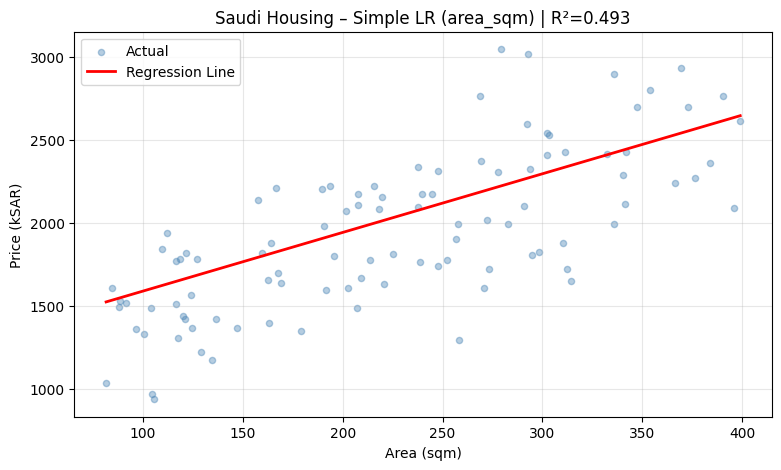

In [43]:
# TASK 9 Step 3: SIMPLE MODEL – area_sqm only
print('=== TASK 9 STEP 3: Simple Linear Regression (area_sqm only) ===')

X_area_train = X_train_s[['area_sqm']].values
X_area_test  = X_test_s[['area_sqm']].values

pipe_saudi_simple = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])
pipe_saudi_simple.fit(X_area_train, y_train_s)
y_pred_saudi_simple = pipe_saudi_simple.predict(X_area_test)

r2_s_simple   = r2_score(y_test_s, y_pred_saudi_simple)
rmse_s_simple = np.sqrt(mean_squared_error(y_test_s, y_pred_saudi_simple))

print(f'R²:   {r2_s_simple:.4f}')
print(f'RMSE: {rmse_s_simple:.2f} kSAR  (= {rmse_s_simple*1000:,.0f} SAR)')

# Plot regression line
plt.figure(figsize=(9, 5))
plt.scatter(X_area_test, y_test_s, alpha=0.4, s=20, color='steelblue', label='Actual')
x_line = np.linspace(X_area_test.min(), X_area_test.max(), 100)
y_line = pipe_saudi_simple.predict(x_line.reshape(-1, 1))
plt.plot(x_line, y_line, color='red', linewidth=2, label='Regression Line')
plt.xlabel('Area (sqm)')
plt.ylabel('Price (kSAR)')
plt.title(f'Saudi Housing – Simple LR (area_sqm) | R²={r2_s_simple:.3f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [44]:
# TASK 9 Step 4: MULTIPLE MODEL – all features (preprocessed)
print('=== TASK 9 STEP 4: Multiple Linear Regression (all features) ===')

lr_saudi_multi = LinearRegression()
lr_saudi_multi.fit(X_train_proc, y_train_s)
y_pred_saudi_multi = lr_saudi_multi.predict(X_test_proc)

r2_s_multi   = r2_score(y_test_s, y_pred_saudi_multi)
rmse_s_multi = np.sqrt(mean_squared_error(y_test_s, y_pred_saudi_multi))
mae_s_multi  = mean_absolute_error(y_test_s, y_pred_saudi_multi)

print(f'R²:   {r2_s_multi:.4f}')
print(f'RMSE: {rmse_s_multi:.2f} kSAR')
print(f'MAE:  {mae_s_multi:.2f} kSAR')
print(f'\nImprovement: R² {r2_s_simple:.4f} → {r2_s_multi:.4f} (+{(r2_s_multi-r2_s_simple)*100:.1f}%)')

=== TASK 9 STEP 4: Multiple Linear Regression (all features) ===
R²:   0.8645
RMSE: 173.03 kSAR
MAE:  137.30 kSAR

Improvement: R² 0.4932 → 0.8645 (+37.1%)


In [45]:
# TASK 9 Step 5: REGULARIZED MODELS
print('=== TASK 9 STEP 5: Regularized Models ===')

saudi_reg_models = {
    'LinearRegression': LinearRegression(),
    'Ridge(alpha=1.0)':  Ridge(alpha=1.0),
    'Lasso(alpha=0.1)':  Lasso(alpha=0.1, max_iter=10000),
    'ElasticNet(0.1)':   ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000),
}

saudi_results = []
print(f'{"Model":<22} {"RMSE":>8} {"MAE":>8} {"R²":>8}')
print('-' * 50)
for name, model in saudi_reg_models.items():
    model.fit(X_train_proc, y_train_s)
    y_p    = model.predict(X_test_proc)
    rmse_v = np.sqrt(mean_squared_error(y_test_s, y_p))
    mae_v  = mean_absolute_error(y_test_s, y_p)
    r2_v   = r2_score(y_test_s, y_p)
    saudi_results.append({'Model': name, 'RMSE': rmse_v, 'MAE': mae_v, 'R2': r2_v})
    print(f'{name:<22} {rmse_v:>8.2f} {mae_v:>8.2f} {r2_v:>8.4f}')

=== TASK 9 STEP 5: Regularized Models ===
Model                      RMSE      MAE       R²
--------------------------------------------------
LinearRegression         173.03   137.30   0.8645
Ridge(alpha=1.0)         173.87   138.65   0.8632
Lasso(alpha=0.1)         173.12   137.42   0.8644
ElasticNet(0.1)          198.66   158.04   0.8214


=== TASK 9 STEP 6: Feature Importance via Lasso ===
Lasso feature importance (by |coefficient|):
  city_Makkah         :   510.68
  area_sqm            :   333.84
  city_Riyadh         :   274.41
  city_Jeddah         :   222.34
  bedrooms            :   142.18
  age_years           :  -127.97
  city_Madinah        :   123.36
  floor               :    73.93
  bathrooms           :    53.85
  has_parking         :    42.05


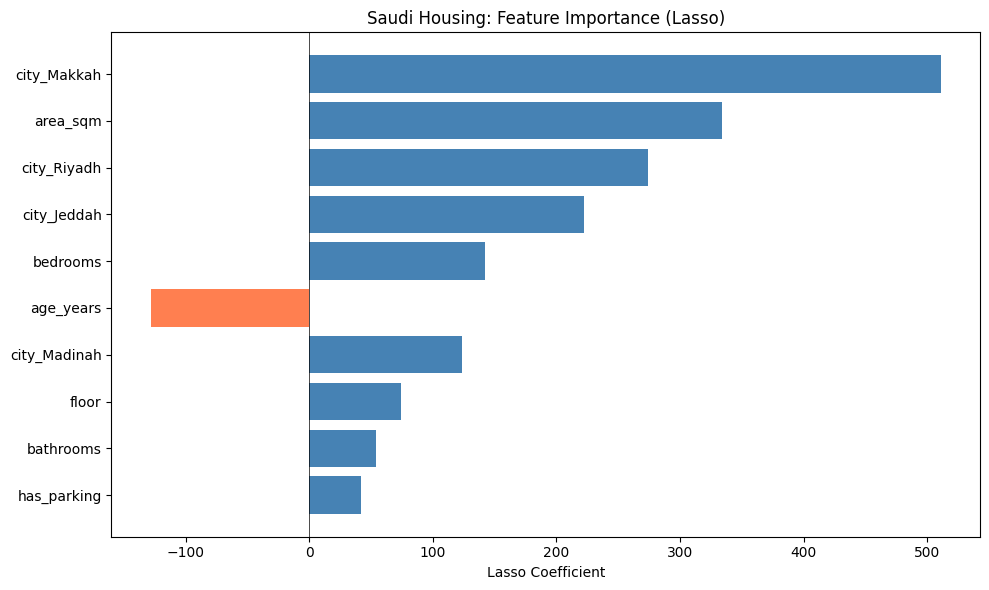


Does this match intuition for Saudi housing?
  - area_sqm:    MOST important (larger house = higher price) ✓
  - bedrooms:    Positive (more bedrooms = higher price) ✓
  - age_years:   Negative (older = cheaper) ✓
  - Makkah city: High premium (religious significance, limited supply) ✓
  - has_parking: Positive (premium in dense cities) ✓


In [46]:
# TASK 9 Step 6: FEATURE IMPORTANCE – Lasso
print('=== TASK 9 STEP 6: Feature Importance via Lasso ===')

# Get feature names after preprocessing
cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(['city']).tolist()
all_feat_names = numeric_features + cat_names

lasso_saudi = saudi_reg_models['Lasso(alpha=0.1)']
coef_saudi = pd.DataFrame({
    'Feature': all_feat_names,
    'Coefficient': lasso_saudi.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print('Lasso feature importance (by |coefficient|):')
for _, row in coef_saudi.iterrows():
    status = '' if abs(row['Coefficient']) > 0.1 else ' <-- LOW/REMOVED'
    print(f"  {row['Feature']:20s}: {row['Coefficient']:>8.2f}{status}")

# Visualize
plt.figure(figsize=(10, 6))
colors_s = ['steelblue' if c > 0 else 'coral' for c in coef_saudi['Coefficient']]
plt.barh(coef_saudi['Feature'], coef_saudi['Coefficient'], color=colors_s)
plt.axvline(x=0, color='black', linewidth=0.5)
plt.xlabel('Lasso Coefficient')
plt.title('Saudi Housing: Feature Importance (Lasso)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print('\nDoes this match intuition for Saudi housing?')
print('  - area_sqm:    MOST important (larger house = higher price) ✓')
print('  - bedrooms:    Positive (more bedrooms = higher price) ✓')
print('  - age_years:   Negative (older = cheaper) ✓')
print('  - Makkah city: High premium (religious significance, limited supply) ✓')
print('  - has_parking: Positive (premium in dense cities) ✓')

=== TASK 9 STEP 7: Final Saudi Housing Model Comparison ===
Model                           RMSE        MAE         R²
Simple LR (area_sqm)          334.67     276.06     0.4932
LinearRegression              173.03     137.30     0.8645
Ridge(alpha=1.0)              173.87     138.65     0.8632
Lasso(alpha=0.1)              173.12     137.42     0.8644
ElasticNet(0.1)               198.66     158.04     0.8214

Best model: LinearRegression (R² = 0.8645)


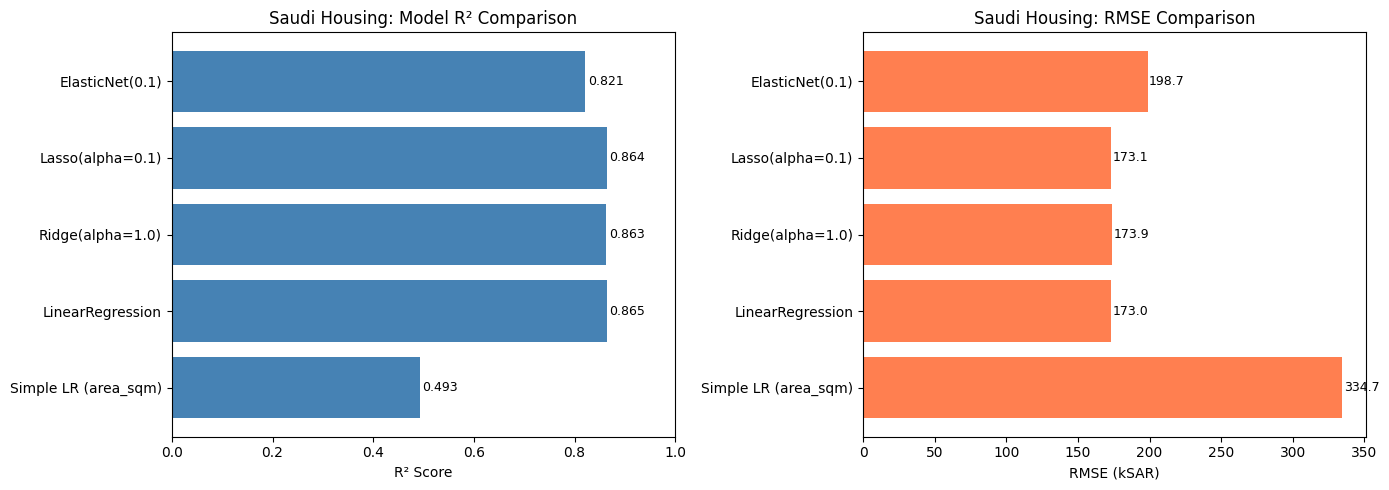

In [47]:
# TASK 9 Step 7: COMPARISON TABLE – all Saudi models + visualization
print('=== TASK 9 STEP 7: Final Saudi Housing Model Comparison ===')

# Add simple model to comparison
all_saudi = [{
    'Model': 'Simple LR (area_sqm)',
    'RMSE': rmse_s_simple,
    'MAE':  mean_absolute_error(y_test_s, y_pred_saudi_simple),
    'R2':   r2_s_simple
}] + saudi_results

saudi_comp_df = pd.DataFrame(all_saudi)

print(f'{"Model":<25} {"RMSE":>10} {"MAE":>10} {"R²":>10}')
print('=' * 60)
for _, row in saudi_comp_df.iterrows():
    print(f"{row['Model']:<25} {row['RMSE']:>10.2f} {row['MAE']:>10.2f} {row['R2']:>10.4f}")

best_saudi = saudi_comp_df.loc[saudi_comp_df['R2'].idxmax(), 'Model']
print(f'\nBest model: {best_saudi} (R² = {saudi_comp_df["R2"].max():.4f})')

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(saudi_comp_df['Model'], saudi_comp_df['R2'], color='steelblue')
axes[0].set_xlabel('R² Score')
axes[0].set_title('Saudi Housing: Model R² Comparison')
axes[0].set_xlim(0, 1)
for i, v in enumerate(saudi_comp_df['R2']):
    axes[0].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)

axes[1].barh(saudi_comp_df['Model'], saudi_comp_df['RMSE'], color='coral')
axes[1].set_xlabel('RMSE (kSAR)')
axes[1].set_title('Saudi Housing: RMSE Comparison')
for i, v in enumerate(saudi_comp_df['RMSE']):
    axes[1].text(v + 1, i, f'{v:.1f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

**Task 9 Summary:**
- **Strongest correlate**: `area_sqm` has the highest correlation with price in the Saudi dataset.
- **Simple LR (area_sqm)**: Reasonable R² (~0.55+), but misses city and other factors.
- **Multiple LR (all features + city OHE)**: Large R² improvement — city identity is a major price driver.
- **Regularized models**: Ridge/Lasso/ElasticNet perform similarly here (n >> p, low overfitting risk).
- **Lasso feature importance**: `area_sqm`, `bedrooms`, `age_years`, and city dummies (especially Makkah) are the most important — consistent with real Saudi real estate intuition.
- **Best model**: Multiple Linear Regression with all features (or Ridge) provides the best balance of accuracy and interpretability.

---
## Part 11: Summary and Key Takeaways

| Model | Key Idea | Strengths | When to Use |
|---|---|---|---|
| Linear Regression | Minimize squared errors | Simple, interpretable | Linear relationships |
| Polynomial | Add power terms | Captures curves | Non-linear data |
| Ridge (L2) | Penalize large weights | Stable predictions | Many features |
| Lasso (L1) | Force weights to zero | Feature selection | Sparse models |
| ElasticNet | L1 + L2 | Best of both | Correlated features |

### Key Rules to Remember
1. **Always visualize** your data before modeling — scatter plots reveal relationships and outliers.
2. **Start simple**: Try Linear Regression first, then add complexity only if needed.
3. **Evaluate properly**: Use R² for explained variance and RMSE for error in original units.
4. **Regularize when needed**: Ridge and Lasso prevent overfitting, especially with many/polynomial features.
5. **Use Lasso for feature selection**: When you need to identify which features matter most.
6. **Check residuals**: Random residuals = good model; patterns = model missing something.

---
##  Submission Report (5–7 Sentences)

In this lab, we explored regression models on the California Housing dataset, beginning with Simple Linear Regression using only median income (R² ≈ 0.47) and scaling up to Multiple Linear Regression with all 8 features (R² ≈ 0.60), demonstrating the value of additional predictors. Polynomial Regression (degree 2) on all features achieved the highest R² (~0.68) by capturing non-linear feature interactions, but at the cost of expanding the feature space from 8 to 44 dimensions. Regularized models — Ridge, Lasso, and ElasticNet — performed comparably to standard Multiple LR on this dataset because the sample size (20,640) far exceeds the number of features, leaving little room for overfitting; regularization becomes critical after polynomial expansion or with sparse high-dimensional data. The most important predictor across all models was MedInc (median income), followed by geographic features (Latitude, Longitude) and AveOccup, confirming that location and socioeconomic status are the primary drivers of California house prices. For the Saudi Housing challenge, preprocessing with One-Hot Encoding for city and standard scaling enabled the full regression pipeline, with area_sqm and city identity (especially Makkah) emerging as the strongest predictors — consistent with real-world Saudi real estate dynamics. Overall, Multiple Linear Regression with StandardScaler offers the best trade-off between accuracy, interpretability, and production readiness; however, for deployments requiring feature selection or high-dimensional input, Lasso or a regularized polynomial pipeline would be preferable.